In [1]:
# The purpose of this project is to:
# investigate the column density of mixing ratios 
# of 5 different cases ranging from e=0.0167 to e=0.4 for constant zero obliquity

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.ticker as ticker

In [2]:
# define eccentricity range

e_range =['e0','e01','e02','e03','e04']

#e_range =['e01','e02','e03','e04']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0_branch.001/atm/hist/')

# define specific path
          

Path_H2O        = []
Path_H2         = []
Path_H          = []
Path_CH4        = []
Path_H2O        = []
Path_H2O2       = []
Path_HO2        = []
Path_OH         = []
Path_T          = []
Path_O3         = []
Path_U          = []

#Path_O2         = []




for i in range(len(data_dir_file)):
          
    Path_H2O.append(data_dir_file[i]+'H2O_'+ e_range[i] +'_obl0_merge.nc')
    Path_H2.append(data_dir_file[i]+'H2_'+ e_range[i] +'_obl0_merge.nc')
    Path_H.append(data_dir_file[i]+'H_'+ e_range[i] +'_obl0_merge.nc')
    Path_H2O2.append(data_dir_file[i]+'H2O2_'+ e_range[i] +'_obl0_merge.nc')
    Path_CH4.append(data_dir_file[i]+'CH4_'+ e_range[i] +'_obl0_merge.nc')
    Path_HO2.append(data_dir_file[i]+'HO2_'+ e_range[i] +'_obl0_merge.nc')
    Path_OH.append(data_dir_file[i]+'OH_'+ e_range[i] +'_obl0_merge.nc')
    
    Path_T.append(data_dir_file[i]+'T_'+ e_range[i] +'_obl0_merge.nc')
    
    Path_O3.append(data_dir_file[i]+'O3_'+ e_range[i] +'_obl0_merge.nc')
    Path_U.append(data_dir_file[i]+'U_'+ e_range[i] +'_obl0_merge.nc')
    #Path_O2.append(data_dir_file[i]+'O2_'+ e_range[i] +'_obl0.nc')
    



# Import data

# each file has 5 case elements

H2_obl0           =[]
H_obl0            =[]
H2O2_obl0         =[]
HO2_obl0          =[]
CH4_obl0          =[]
OH_obl0           =[]
H2O_obl0          =[]

O3_obl0           =[]

T_obl0            =[]

U_obl0            =[]

#O2_obl0            =[]




for i in range(len(e_range)):

          
    H2_obl0.append(xr.open_mfdataset(Path_H2[i]))
    H_obl0.append(xr.open_mfdataset(Path_H[i]))
    H2O2_obl0.append(xr.open_mfdataset(Path_H2O2[i]))
    HO2_obl0.append(xr.open_mfdataset(Path_HO2[i]))
    CH4_obl0.append(xr.open_mfdataset(Path_CH4[i]))
    OH_obl0.append(xr.open_mfdataset(Path_OH[i]))
    H2O_obl0.append(xr.open_mfdataset(Path_H2O[i]))
    
    T_obl0.append(xr.open_mfdataset(Path_T[i]))
    
    O3_obl0.append(xr.open_mfdataset(Path_O3[i]))
    
    U_obl0.append(xr.open_mfdataset(Path_U[i]))
    
    #O2_obl0.append(xr.open_mfdataset(Path_O2[i]))


In [3]:
# define eccentricity range

# for O2 only because my e = 0.0167 case does not have O2 in namelist definition

e_range =['e01','e02','e03','e04']

# define path 

data_dir_file = []

for i in range(len(e_range)):
    data_dir_file.append('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.'+ e_range[i]+'_obl0_branch.001/atm/hist/')

# define specific path
          
Path_O2         = []


for i in range(len(data_dir_file)):
          
    Path_O2.append(data_dir_file[i]+'O2_'+ e_range[i] +'_obl0.nc')
    

# Import data

# each file has 5 case elements

O2_obl0            =[]


for i in range(len(e_range)):
    O2_obl0.append(xr.open_mfdataset(Path_O2[i]))


In [4]:
# H2O_obl0[3].H2O.mean(dim='lon').isel(time=-1).plot.imshow(x='lat',cmap='RdYlBu_r',yscale='log',ylim=(1000, 100))

# O3_obl0[4].O3.mean(dim='lon').mean(dim='time').plot.imshow(x='lat',cmap='RdYlBu_r',yscale='log',ylim=(1000, 1))

In [5]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0) #open the file

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    if (time == False):
        try:
            DS = DS.mean(dim='time')#take time mean
        except:
            print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above



In [6]:
# O3_e04_global=LatWeightAnyVar(O3_obl0[4].O3)*10**6
# O3_e0_global=LatWeightAnyVar(O3_obl0[0].O3)*10**6

# diff_O3=O3_e04_global-O3_e0_global

# O3_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',yincrease=False)

# O3_e0_global.plot(y='lev',yscale='log',xscale='log',label='e01',yincrease=False)

# diff_O3.plot(y='lev',yscale='log',xscale='log',label='e04-e01',yincrease=False)

# plt.legend()

# plt.xlabel('Mixing Ratios in PPMV')

# plt.title('Ozone Mixing Ratios')

In [7]:
def scale_height(DS):
    K        = 1.38 * 10**(-23)       # J·K−1
    T_air    = DS.mean(dim='lev')     # atmospheric mean temperature in K
    
    print('T_air',T_air.values)
    
    u        = 1.660*10**(-27)        # hydrogen mass in kg
    m        = 28.964 * u             # mean atmospheric molecular mass in kg
    g        = 9.8                    # m/s2
    H        = (K*T_air/(m*g))/1000     # in km

    return H

In [8]:
def Alt_conversion(DS):
    
    H=scale_height(DS)
    
    Z=-np.log(DS.lev/DS.lev[-1])*H
    
    return Z

In [9]:
# get vertical Temperature structure

T_e04_global=LatWeightAnyVar(T_obl0[4].T[0:168,:,:,:])

T_e0_global =LatWeightAnyVar(T_obl0[0].T[0:96,:,:,:])

# get altitude from pressure 

Z_e0  = Alt_conversion(T_e0_global)

Z_e04 = Alt_conversion(T_e04_global)

# OH Mixing Ratios

OH_e04_global=LatWeightAnyVar(OH_obl0[4].OH[120:168,:,:,:])*10**6
OH_e0_global=LatWeightAnyVar(OH_obl0[0].OH[48:96,:,:,:])*10**6

# H2 Mixing Ratios

H2_e04_global=LatWeightAnyVar(H2_obl0[4].H2[120:168,:,:,:])*10**6
H2_e03_global=LatWeightAnyVar(H2_obl0[3].H2[0:48,:,:,:])*10**6
H2_e02_global=LatWeightAnyVar(H2_obl0[2].H2[0:48,:,:,:])*10**6
H2_e01_global=LatWeightAnyVar(H2_obl0[1].H2[60:108,:,:,:])*10**6
H2_e0_global=LatWeightAnyVar(H2_obl0[0].H2[48:96,:,:,:])*10**6

# H Mixing Ratios

H_e04_global=LatWeightAnyVar(H_obl0[4].H[120:168,:,:,:])*10**6
H_e03_global=LatWeightAnyVar(H_obl0[3].H[0:48,:,:,:])*10**6
H_e02_global=LatWeightAnyVar(H_obl0[2].H[0:48,:,:,:])*10**6
H_e01_global=LatWeightAnyVar(H_obl0[1].H[60:108,:,:,:])*10**6
H_e0_global=LatWeightAnyVar(H_obl0[0].H[48:96,:,:,:])*10**6

# H2O Mixing Ratios

H2O_e04_global      =LatWeightAnyVar(H2O_obl0[4].H2O[120:168,:,:,:])*10**6
H2O_e03_global      =LatWeightAnyVar(H2O_obl0[3].H2O[0:48,:,:,:])*10**6
H2O_e02_global      =LatWeightAnyVar(H2O_obl0[2].H2O[0:48,:,:,:])*10**6
H2O_e01_global      =LatWeightAnyVar(H2O_obl0[1].H2O[60:108,:,:,:])*10**6
H2O_e0_global=LatWeightAnyVar(H2O_obl0[0].H2O[48:96,:,:,:])*10**6

# CH4 Mixing Ratios

CH4_e04_global=LatWeightAnyVar(CH4_obl0[4].CH4[120:168,:,:,:])*10**6
CH4_e03_global=LatWeightAnyVar(CH4_obl0[3].CH4[0:48,:,:,:])*10**6
CH4_e02_global=LatWeightAnyVar(CH4_obl0[2].CH4[0:48,:,:,:])*10**6
CH4_e01_global=LatWeightAnyVar(CH4_obl0[1].CH4[60:108,:,:,:])*10**6
CH4_e0_global=LatWeightAnyVar(CH4_obl0[0].CH4[48:96,:,:,:])*10**6

# O2 Mixing Ratios

O2_e04_global=LatWeightAnyVar(O2_obl0[3].O2[0:12,:,:,:])*10**6
O2_e01_global=LatWeightAnyVar(O2_obl0[0].O2[0:12,:,:,:])*10**6

# O3 Mixing Ratios

O3_e04_global=LatWeightAnyVar(O3_obl0[4].O3[120:168,:,:,:])*10**6
O3_e0_global =LatWeightAnyVar(O3_obl0[0].O3[48:96,:,:,:])*10**6

T_air 256.3918363528358
T_air 256.2364086708334


Text(0.5, 1.0, 'OH Mixing Ratios')

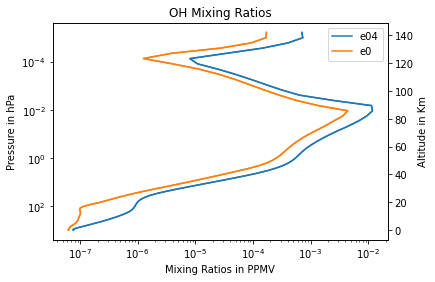

In [10]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

OH_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

OH_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(OH_e04_global.values,Z_e04.values,label='e04')

ax2.plot(OH_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('OH Mixing Ratios')


H2_MR_E0 3.312599543431055
H2_MR_E04 21.931338063361203


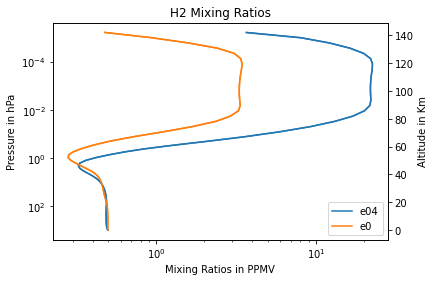

In [11]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

H2_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

H2_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(H2_e04_global.values,Z_e04.values,label='e04')

ax2.plot(H2_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('H2 Mixing Ratios')

print('H2_MR_E0',H2_e0_global.isel(lev=11).values)
print('H2_MR_E04',H2_e04_global.isel(lev=11).values)

H_MR_E0 1.8181909032622545
H_MR_E04 9.376535825351198


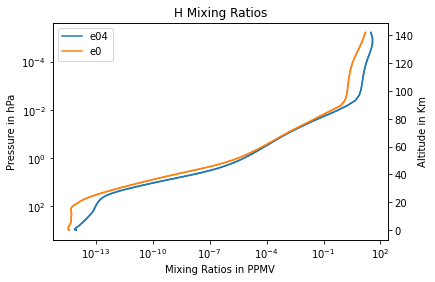

In [12]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

H_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

H_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(H_e04_global.values,Z_e04.values,label='e04')

ax2.plot(H_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('H Mixing Ratios')

print('H_MR_E0',H_e0_global.isel(lev=11).values)
print('H_MR_E04',H_e04_global.isel(lev=11).values)

CH4_MR_E0 0.0016320132574055718
CH4_MR_E04 0.0026921129441477643


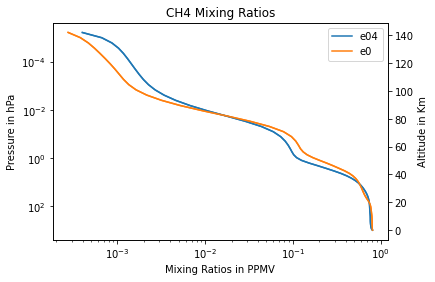

In [13]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

CH4_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

CH4_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(CH4_e04_global.values,Z_e04.values,label='e04')

ax2.plot(CH4_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('CH4 Mixing Ratios')

print('CH4_MR_E0',CH4_e0_global.isel(lev=11).values)
print('CH4_MR_E04',CH4_e04_global.isel(lev=11).values)

Text(0.5, 1.0, 'O3 Mixing Ratios')

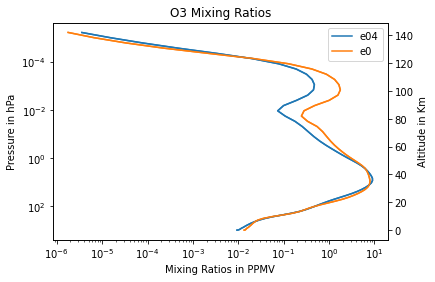

In [14]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

O3_e04_global.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

O3_e0_global.plot(y='lev',yscale='log',xscale='log',label='e0',ax=ax1, yincrease=False)

ax2.plot(O3_e04_global.values,Z_e04.values,label='e04')

ax2.plot(O3_e0_global.values,Z_e0.values,label='e0')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('O3 Mixing Ratios')

Text(0.5, 1.0, 'O3 Mixing Ratios Difference')

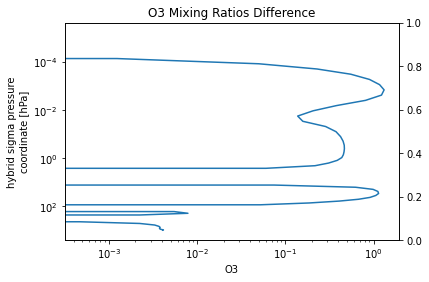

In [15]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

(O3_e0_global-O3_e04_global).plot(y='lev',yscale='log',xscale='log',label='E0-E04',ax=ax1, yincrease=False)


# ax2.plot(O3_e04_global.values,Z_e04.values,label='e04')

# ax2.plot(O3_e0_global.values,Z_e0.values,label='e0')

# ax2.set_xscale('log')

# ax2.legend()

# ax2.set_xlabel('Mixing Ratios in PPMV')

# ax2.set_ylabel('Altitude in Km')

# ax1.set_xlabel('Mixing Ratios in PPMV')

# ax1.set_ylabel('Pressure in hPa')

plt.title('O3 Mixing Ratios Difference')

In [16]:
#%% define latitudinal weighting function

def LatWeightAnyVar_timeframe(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=2)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

In [17]:
# O3_e04_global_time=LatWeightAnyVar_timeframe(O3_obl0[4].O3)*10**6

# O3_e0_global_time=LatWeightAnyVar_timeframe(O3_obl0[0].O3)*10**6

# diff_O3_time=O3_e04_global_time-O3_e0_global_time

# diff_O3_time.isel(lev=28).plot(label='e04-e01')

# O3_e04_global_time.isel(lev=28).plot(label='e04')

# O3_e0_global_time.isel(lev=28).plot(label='e0')


# plt.legend()

# plt.title('Time Series of O3 Mixing Ratio and Difference')

# plt.ylabel('O3 mixing ratio in ppmv')

In [18]:
# O3_e0_global_time.lev.isel(lev=28)

H2O_MR_E01_100km 0.23233504897917825
H2O_MR_E04_100km 3.386603956775717
H2O_MR_E01_100mb 3.971479979889421
H2O_MR_E04_100mb 326.32895711997674


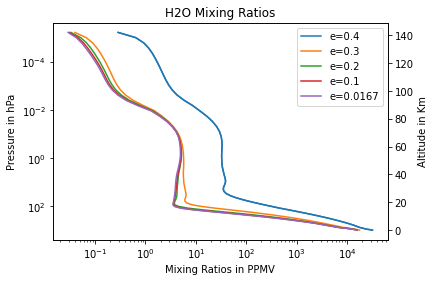

In [19]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

H2O_e04_global.plot(y='lev',yscale='log',xscale='log',label='e=0.4',ax=ax1, yincrease=False)

H2O_e03_global.plot(y='lev',yscale='log',xscale='log',label='e=0.3',ax=ax1, yincrease=False)

H2O_e02_global.plot(y='lev',yscale='log',xscale='log',label='e=0.2',ax=ax1, yincrease=False)

H2O_e01_global.plot(y='lev',yscale='log',xscale='log',label='e=0.1',ax=ax1, yincrease=False)

H2O_e0_global.plot(y='lev',yscale='log',xscale='log',label='e=0.0167',ax=ax1, yincrease=False)


ax2.plot(H2O_e04_global.values,Z_e04.values)

ax2.set_xscale('log')

ax1.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('H2O Mixing Ratios')


print('H2O_MR_E01_100km',H2O_e01_global.isel(lev=11).values)
print('H2O_MR_E04_100km',H2O_e04_global.isel(lev=11).values)

print('H2O_MR_E01_100mb',H2O_e01_global.isel(lev=-22).values)
print('H2O_MR_E04_100mb',H2O_e04_global.isel(lev=-22).values)

Text(0, 0.5, 'Pressure in hPa')

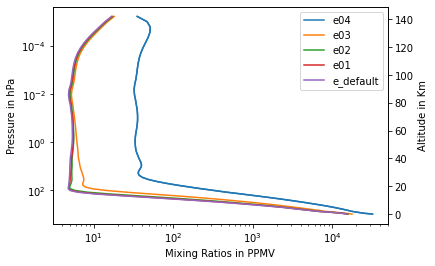

In [20]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

combined_e04=H2O_e04_global+H2_e04_global+H_e04_global+CH4_e04_global

combined_e04.plot(y='lev',yscale='log',xscale='log',label='e04',ax=ax1, yincrease=False)

(H2O_e03_global+H2_e03_global+H_e03_global+CH4_e03_global).plot(y='lev',yscale='log',xscale='log',label='e03',ax=ax1, yincrease=False)

(H2O_e02_global+H2_e02_global+H_e02_global+CH4_e02_global).plot(y='lev',yscale='log',xscale='log',label='e02',ax=ax1, yincrease=False)

(H2O_e01_global+H2_e01_global+H_e01_global+CH4_e01_global).plot(y='lev',yscale='log',xscale='log',label='e01',ax=ax1, yincrease=False)

(H2O_e0_global+H2_e0_global+H_e0_global+CH4_e0_global).plot(y='lev',yscale='log',xscale='log',label='e_default',ax=ax1, yincrease=False)


ax2.plot(combined_e04.values,Z_e04.values)

ax2.set_xscale('log')

ax1.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

#plt.title('H2O Mixing Ratios')


In [21]:
(H2O_e0_global+H2_e0_global+H_e0_global+CH4_e0_global).values

print("4.79855944e+00")

4.79855944e+00


In [22]:
combined_e04.values
print("3.62436001e+01")

3.62436001e+01


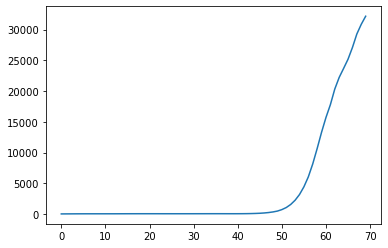

In [23]:
plt.plot((H2O_e04_global+H2_e04_global).values)

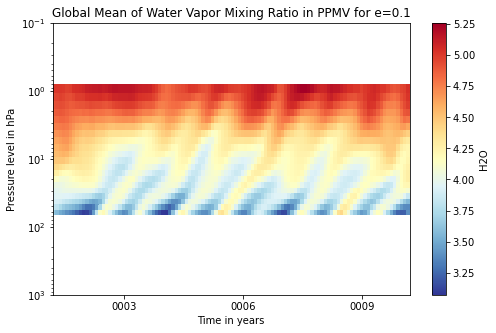

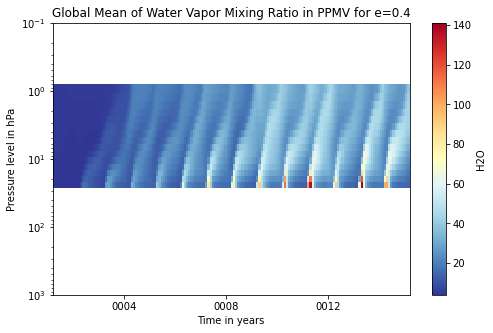

In [24]:
#fig, axes = plt.subplots()

# for stratopause 

H2O_e01_time= LatWeightAnyVar_timeframe(H2O_obl0[1].H2O[:,-44:-24,:,:])*10**6 

H2O_e04_time= LatWeightAnyVar_timeframe(H2O_obl0[4].H2O[:,-44:-29,:,:])*10**6 


H2O_e01_time.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))#,vmin=2, vmax=7)
plt.ylim([1000,0.1])

plt.title('Global Mean of Water Vapor Mixing Ratio in PPMV for e=0.1',fontsize=12)
plt.xlabel('Time in years')
plt.ylabel("Pressure level in hPa")
plt.show()

H2O_e04_time.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))#,vmin=10,vmax=90)
plt.title('Global Mean of Water Vapor Mixing Ratio in PPMV for e=0.4',fontsize=12)
plt.xlabel('Time in years')
plt.ylabel("Pressure level in hPa")
plt.ylim([1000,0.1])

plt.show()

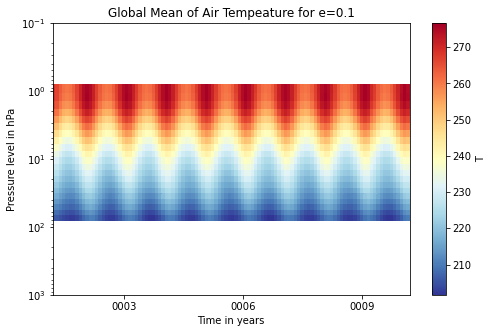

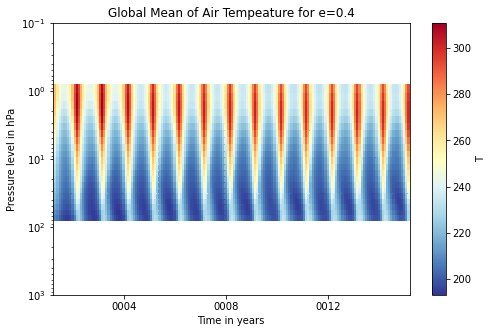

In [25]:
# for stratopause 

T_e01_time= LatWeightAnyVar_timeframe(T_obl0[1].T[:,-44:-23,:,:])

T_e04_time= LatWeightAnyVar_timeframe(T_obl0[4].T[:,-44:-23,:,:])


T_e01_time.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))#,ax=axes)#,vmin=8000, vmax=10000)
plt.ylim([1000,0.1])
plt.title('Global Mean of Air Tempeature for e=0.1',fontsize=12)
plt.xlabel('Time in years')
plt.ylabel("Pressure level in hPa")
plt.show()

T_e04_time.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))#,ax=axes)
plt.ylim([1000,0.1])
plt.title('Global Mean of Air Tempeature for e=0.4',fontsize=12)
plt.xlabel('Time in years')
plt.ylabel("Pressure level in hPa")
plt.show()

In [26]:
print('H2O_MR_E01_coldtrap',H2O_e01_global.values[-24]*10**6)

print('Lev',H2O_e01_global.lev.values[-24])

print('H2O_MR_E01_coldtrap',H2O_e04_global.values[-29]*10**6)

print('Lev',H2O_e04_global.lev.values[-29])

H2O_MR_E01_coldtrap 3614008.1595688886
Lev 73.75095784664154
H2O_MR_E01_coldtrap 40062089.366253875
Lev 29.7279991209507


Text(0.5, 1.0, 'O2 Mixing Ratios')

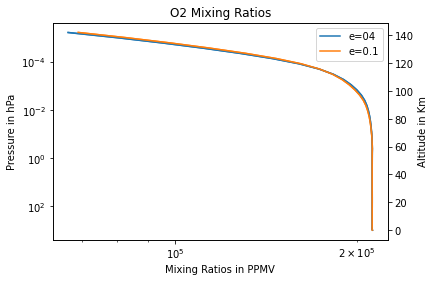

In [27]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

O2_e04_global.plot(y='lev',yscale='log',xscale='log',label='e=04',ax=ax1, yincrease=False)

O2_e01_global.plot(y='lev',yscale='log',xscale='log',label='e=0.1',ax=ax1, yincrease=False)

ax2.plot(O2_e04_global.values,Z_e04.values,label='e=04')

ax2.plot(O2_e01_global.values,Z_e0.values,label='e=0.1')

ax2.set_xscale('log')

ax2.legend()

ax2.set_xlabel('Mixing Ratios in PPMV')

ax2.set_ylabel('Altitude in Km')

ax1.set_xlabel('Mixing Ratios in PPMV')

ax1.set_ylabel('Pressure in hPa')

plt.title('O2 Mixing Ratios')

In [28]:
# find the corresponding pressure of 100 km homopuase

h=100  # 100 km homopause

H_e04=scale_height(T_e04_global).values

p_homo_e04=T_e04_global.lev[-1].values*np.exp(-h/H_e04)

print('p_homo_e04',p_homo_e04)


H_e0=scale_height(T_e0_global).values

p_homo_e0=T_e0_global.lev[-1].values*np.exp(-h/H_e0)

print('p_homo_e0',p_homo_e0)

T_air 256.2364086708334
p_homo_e04 0.0016207163228698998
T_air 256.3918363528358
p_homo_e0 0.0016338612816634629


In [29]:
from astropy.table import QTable

import astropy.units as u

Species = np.array(['H', 'OH', 'H2','H2O'])


MR_e0     = [H_e0_global.values[11], OH_e0_global.values[11],H2_e0_global.values[11],H2O_e0_global.values[11]]


MR_e04    = [H_e04_global.values[11], OH_e04_global.values[11],H2_e04_global.values[11],H2O_e04_global.values[11]]

t = QTable([Species, MR_e0, MR_e04],
           
names=('Species', 'MR_e0(model top 0.00145846)','MR_e04(model top 0.00145846)'))


t
           

Species,MR_e0(model top 0.00145846),MR_e04(model top 0.00145846)
str3,float64,float64
H,1.8181909032622545,9.376535825351198
OH,0.00015453250679520037,0.0003105790632295954
H2,3.312599543431055,21.931338063361203
H2O,0.21799312978779245,3.386603956775717


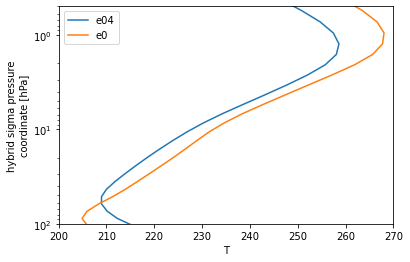

In [30]:
T_e04_thermo=LatWeightAnyVar(T_obl0[4].T)

T_e04_thermo.plot(y='lev',yscale='log',label='e04',yincrease=False)

T_e0_thermo=LatWeightAnyVar(T_obl0[0].T)

T_e0_thermo.plot(y='lev',yscale='log',label='e0',yincrease=False)

plt.ylim([100,0.5])

plt.xlim([200,270])

plt.legend()


In [31]:
# for stratopause 

# lev[-22] conventional 100 mb level (tropopause) e04 e01

T_e0_thermo.values

array([604.61886351, 556.43370692, 490.43742982, 416.42792201,
       342.30312088, 279.64507584, 238.26737886, 216.27171987,
       206.67062643, 205.08051989, 207.77723433, 212.18047948,
       216.23659692, 217.57186565, 215.88129216, 213.85152594,
       213.28321774, 214.99446876, 219.61288116, 226.77527189,
       235.51084557, 244.67849687, 252.83964102, 258.99846951,
       263.50326383, 266.58534232, 268.03641018, 267.72536075,
       265.66821807, 261.85270335, 257.10549224, 252.17253603,
       247.38489459, 242.73511328, 238.33614024, 234.54156576,
       231.40881523, 228.8043741 , 226.34648893, 223.88050066,
       221.35790206, 218.86976562, 216.39341476, 213.93315725,
       211.28193897, 208.39809091, 205.92564665, 204.90283447,
       205.95637062, 207.90429938, 210.29631423, 212.96930603,
       216.49497121, 221.39095608, 227.79789409, 235.28482093,
       243.35832468, 251.43470605, 259.31961569, 265.99177394,
       271.41750456, 275.28204534, 277.52745813, 279.23

In [32]:
# x=ch4vmr_obl0[3].ch4vmr.time
# y=ch4vmr_obl0[3].ch4vmr.values

# #################### how to make y unit ppmv with xarray.plot??????

# fig, ax = plt.subplots()


# # plot two identical plots
# ax.plot(x, y)

# scale_y = 1e6
# ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x*scale_y))
# ax.yaxis.set_major_formatter(ticks_y)

# ax.set_ylabel('CH4 mixing ratios in ppmv')
# ax.set_xlabel('time in month')

# # vertically integrated co2 mixing ratio in ppmv

In [33]:
# x=ch4vmr_obl0[4].ch4vmr.time
# y=ch4vmr_obl0[4].ch4vmr.values

# #################### how to make y unit ppmv with xarray.plot??????

# fig, ax = plt.subplots()


# # plot two identical plots
# ax.plot(x, y)

# scale_y = 1e6
# ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(x*scale_y))
# ax.yaxis.set_major_formatter(ticks_y)

# ax.set_ylabel('CH4 mixing ratios in ppmv')
# ax.set_xlabel('time in month')

# # vertically integrated co2 mixing ratio in ppmv

In [34]:
File_h0 = "/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e0_obl0.001/atm/hist/b.e21.BWma1850.f19_g17.e0_obl0.001.cam.h0.0001-03.nc" #file name

DataSet_h0 = xr.open_dataset(File_h0,decode_times=False) #open the file and decode time as false

gw = DataSet_h0.gw.values

Pressure = DataSet_h0.lev.values

gw = DataSet_h0.gw.values

#%% define latitudinal weighting function

def LatWeightAnyVar(DS, time = False):
    try:
        DS = DS.mean(dim='lon')#take longitudinal mean
    except:
        print('')
    DS = gw*DS #multiply by gaussian weights
    try:
        DS = np.sum(DS,axis=1)/gw.sum() #weighted mean
    except:
        DS = np.sum(DS,axis=0)/gw.sum() #weighted mean 
    return DS #return a numpy array that has been modified above

In [35]:
H2O_obl0_1 = xr.open_mfdataset('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e01_obl0_branch.001/atm/hist/H2O_e01_obl0.nc')

#%% define ozone column calculation function

def O3_col(ds, time = False, O2_mr = 0.21, lon = True):
    
    g = 9.80616           # gravity acceleration (cm/sec2)
    
    to_DU = 1./2.6867e20  # convert colunm density / cm^2 to Dobson units
    
    N2_mr = 1-O2_mr       # nitrogen mixing ratio
    
    m_avg = ((28*N2_mr)+(O2_mr*32))*1.661e-27 
                          # average weight of atmosphere
                          # calcualte column integrals 
    O3 = ds['O3']         # variables to calcualate hybrid pressure on model interfaces
    
    ps = ds['PS'].values  # surface pressure
    
    p0 =  H2O_obl0_1.P0.values  # constant 
    
    hyai = H2O_obl0_1.hyai.values # constant 
    
    hybi = H2O_obl0_1.hybi.values      # constant
    
    print('P0=',p0)
    print('hyai=',hyai)
    print('hybi=',hybi)
    
    dp = np.ndarray(O3.shape, np.float32)
    
    nt = 1
    try:
        nt = ds['time'].size
    except:
        nt = 0
        
    ny = ds['lat'].size
    nz = ds['lev'].size
    nx = ds['lon'].size
    press = np.ndarray(nz, np.float32)

    
    if (nt > 0):
        for i in range(nt):
            for j in range(ny):
                for k in range(nx):
                    press = hyai * p0 + hybi * ps[i,j,k]
                    for iz in range(nz):
                        dp[i,iz,j,k] = (press[iz+1]-press[iz]) 
    else:
        for j in range(ny):
            for k in range(nx):
                press = hyai * p0 + hybi * ps[j,k]
                for iz in range(nz):
                    dp[iz,j,k] = (press[iz+1]-press[iz])
                    
    #calcualte column integrals 
    O3_mid = O3 * dp / (m_avg*g)
    
    o3col = np.sum(O3_mid, axis = 1) * to_DU           # convert to DU
                                                   # integrate by summing small chunks
    if (lon == False):
        
        o3col  = o3col.mean(dim='lon')
        
    if (time == False):
        
        try:
            o3col  = o3col.mean(dim='time')
        except:
            o3col  = o3col
    print('O3 columns calculated')
    return o3col


In [36]:
O3_col=O3_col(O3_obl0[4], time = False, O2_mr = 0.21, lon = True)

P0= 100000.0
hyai= [4.50049997e-09 7.42010009e-09 1.22337003e-08 2.01700008e-08
 3.32545014e-08 5.48274990e-08 9.03979966e-08 1.49040005e-07
 2.45720003e-07 4.05125007e-07 6.67940014e-07 1.10126496e-06
 1.81564997e-06 2.99349995e-06 4.96299981e-06 8.15065141e-06
 1.34769998e-05 2.23190000e-05 3.67965004e-05 6.06649992e-05
 9.91565030e-05 1.57389994e-04 2.38850000e-04 3.45200009e-04
 4.75134992e-04 6.31804985e-04 8.29154975e-04 1.08274003e-03
 1.40684994e-03 1.81885005e-03 2.33979989e-03 2.99505005e-03
 3.81470006e-03 4.83444985e-03 6.09635003e-03 7.64934998e-03
 9.55010019e-03 1.18640000e-02 1.46655003e-02 1.80380009e-02
 2.20755003e-02 2.68824995e-02 3.25734988e-02 3.92730013e-02
 4.71144989e-02 5.62404990e-02 6.68004975e-02 8.07014182e-02
 9.49410424e-02 1.11693211e-01 1.31401271e-01 1.54586807e-01
 1.81863353e-01 1.74597993e-01 1.66050658e-01 1.55995160e-01
 1.44165412e-01 1.30248308e-01 1.13875568e-01 9.46138576e-02
 7.53444508e-02 5.76589406e-02 4.27346379e-02 3.16426791e-02
 2.52

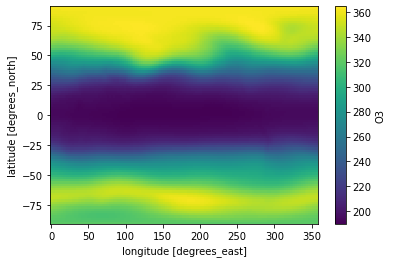

In [37]:
O3_col.plot()

In [38]:
# test if hyai is a constant

H2O_obl0_1 = xr.open_mfdataset('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e01_obl0_branch.001/atm/hist/H2O_e01_obl0.nc')
H2O_obl0_4 = xr.open_mfdataset('/nobackup/pybl/cesm2/archive/b.e21.BWma1850.f19_g17.e04_obl0_branch.001/atm/hist/H2O_e04_obl0.nc')

print((H2O_obl0_4.hyai.values==H2O_obl0_1.hyai.values).all())
print((H2O_obl0_4.hybi.values==H2O_obl0_1.hybi.values).all())
print((H2O_obl0_4.P0.values==H2O_obl0_1.P0.values).all())

True
True
True


In [39]:
def LatWeightAnyVar_lat(DS,lat_low,lat_high,timemean,withlev): #Latitudinal weighting function for any latitudinal bands
    
    DS = DS.mean(dim='lon') #take longitudinal mean
    
    global DS_gw
    global gw_lat
    DS_gw=0
    
 
    gw_lat =0

    
    if (timemean == True) and (withlev == True):
        DS = DS.mean(dim='time')#take time mean

        for i in range(len(DS.lat)):
        
            if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
                DS_gw  += DS[:,i]*gw[i] # multiply by gaussian weights
            
                gw_lat += gw[i]
                
        DS_gw_final = DS_gw.values/gw_lat
        
        
    if (timemean == True) and (withlev == False):
        DS = DS.mean(dim='time')      #take time mean

        for i in range(len(DS.lat)):
        
            if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
                DS_gw  += DS[i]*gw[i] # multiply by gaussian weights
            
                gw_lat += gw[i]
                
            #print(DS_gw)
        DS_gw_final = DS_gw.values/gw_lat
        
    if (timemean == False) and (withlev == True):

        for i in range(len(DS.lat)):
        
            if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
                DS_gw  += DS[:,:,i]*gw[i] # multiply by gaussian weights
            
                gw_lat += gw[i]
                
            #print(DS_gw)
        DS_gw_final = DS_gw.values/gw_lat
        
    elif (timemean == False) and (withlev == False):
            
        for i in range(len(DS.lat)):
        
            if DS.lat[i] >= lat_low and DS.lat[i] <= lat_high :
            
                DS_gw  += DS[:,i]*gw[i] # multiply by gaussian weight
            
                gw_lat += gw[i]
                
            #print(DS_gw)
    
        DS_gw_final = DS_gw.values/np.sum(gw_lat)
        
    return DS_gw_final 

In [40]:
def LatWeightAnyVar_lat_test(DS,lat_low,lat_high,timemean,withlev): #Latitudinal weighting function for any latitudinal bands

    DS = DS.mean(dim='lon') #take longitudinal mean
    
    if (timemean == True) and (withlev == True):
        
        DS = DS.mean(dim='time')#take time mean

        DS =DS[:,lat_low:lat_high] # selecting tropical region

        DS = gw[lat_low:lat_high]*DS #multiply by gaussian weights
        
        DS = np.sum(DS,axis=1)/gw[lat_low:lat_high].sum() #weighted mean
        
    if (timemean == False) and (withlev == True):
        
        #DS = DS.mean(dim='time')#take time mean

        DS =DS[:,:,lat_low:lat_high] # selecting tropical region

        DS = gw[lat_low:lat_high]*DS #multiply by gaussian weights
        
        DS = np.sum(DS,axis=2)/gw[lat_low:lat_high].sum() #weighted mean

    return DS

Text(0.5, 1.0, 'Stratosphere H2O Mixing Ratio Anomaly for e=0.1')

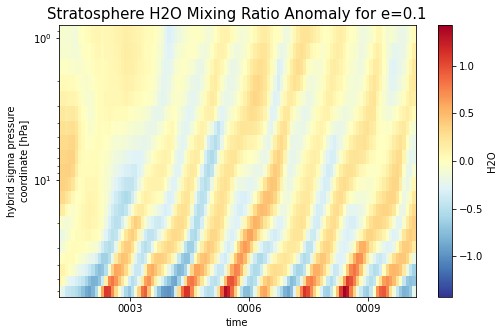

In [41]:
H2O_e01_trop_annomly=((LatWeightAnyVar_lat_test(H2O_obl0[1].H2O[:,-44:-24,:,:]*10**6,lat_low=36,lat_high=-36,timemean=False,withlev=True))-LatWeightAnyVar_lat_test(H2O_obl0[1].H2O[:,-44:-24,:,:]*10**6,lat_low=36,lat_high=-36,timemean=True,withlev=True))
H2O_e01_trop_annomly.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratosphere H2O Mixing Ratio Anomaly for e=0.1',fontsize=15)
#

In [42]:
H2O_obl0[1].H2O.lat[0:2]

<xarray.DataArray 'lat' (lat: 2)>
array([-90.      , -88.105263])
Coordinates:
  * lat      (lat) float64 -90.0 -88.11
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

Text(0.5, 1.0, 'Stratosphere H2O Mixing Ratio Anomaly for e=0.4')

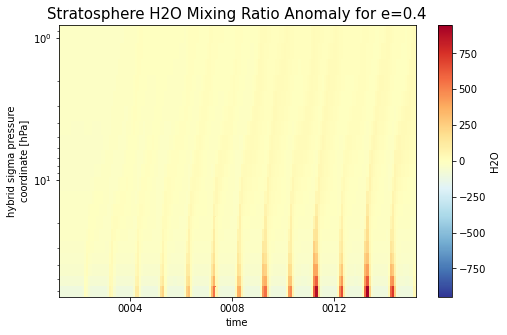

In [43]:
H2O_e04_trop_annomly=((LatWeightAnyVar_lat_test(H2O_obl0[4].H2O[:,-44:-24,:,:]*10**6,lat_low=36,lat_high=-36,timemean=False,withlev=True))-LatWeightAnyVar_lat_test(H2O_obl0[4].H2O[:,-44:-24,:,:]*10**6,lat_low=36,lat_high=-36,timemean=True,withlev=True))
H2O_e04_trop_annomly.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratosphere H2O Mixing Ratio Anomaly for e=0.4',fontsize=15)

Text(0.5, 1.0, 'Stratosphere Temperature Anomaly for e=0.1')

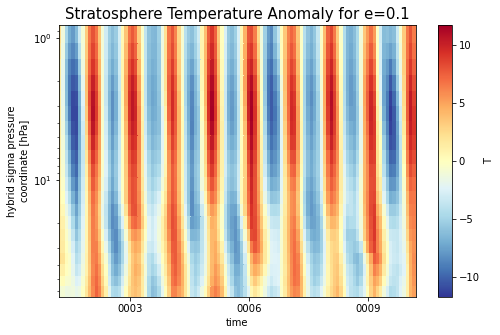

In [44]:
T_e01_trop_annomly=((LatWeightAnyVar_lat_test(T_obl0[1].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True))-LatWeightAnyVar_lat_test(T_obl0[1].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=True,withlev=True))
T_e01_trop_annomly.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratosphere Temperature Anomaly for e=0.1',fontsize=15)
#

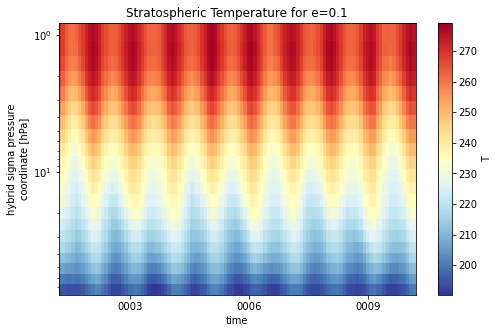

Text(0.5, 1.0, 'Cold Trap Temperature for e=0.1')

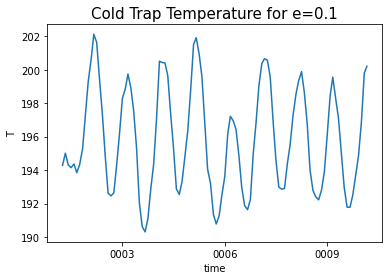

In [45]:
T_e01_trop= LatWeightAnyVar_lat_test(T_obl0[1].T[:,-44:-23,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True)

T_e01_trop.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratospheric Temperature for e=0.1')
plt.show()

T_e01_trop[:,-1].plot()

plt.title('Cold Trap Temperature for e=0.1',fontsize=15)

#


Text(0.5, 1.0, 'Stratosphere Temperature Anomaly for e=0.4')

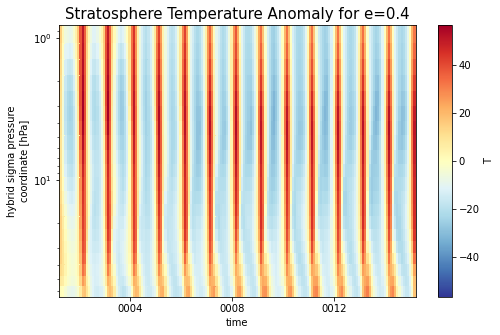

In [46]:
T_e04_trop_annomly=((LatWeightAnyVar_lat_test(T_obl0[4].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True))-LatWeightAnyVar_lat_test(T_obl0[4].T[:,-44:-24,:,:],lat_low=36,lat_high=-36,timemean=True,withlev=True))
T_e04_trop_annomly.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratosphere Temperature Anomaly for e=0.4',fontsize=15)

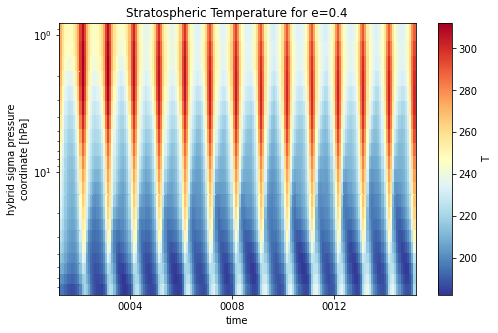

Text(0.5, 1.0, 'Cold Trap Temperature for e=0.4')

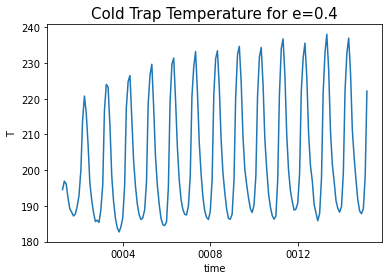

In [47]:
T_e04_trop= LatWeightAnyVar_lat_test(T_obl0[4].T[:,-44:-23,:,:],lat_low=36,lat_high=-36,timemean=False,withlev=True)

T_e04_trop.plot(x='time',cmap='RdYlBu_r',yscale='log',yincrease=False,figsize=(8,5))
plt.title('Stratospheric Temperature for e=0.4')
plt.show()

T_e04_trop[:,-1].plot()

plt.title('Cold Trap Temperature for e=0.4',fontsize=15)

#

But, how should I quantify this correlation?

In [48]:
# Tropical tropopause temperature
TTPT_e_default_mean = LatWeightAnyVar_lat(T_obl0[0].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=True,withlev=False)

TTPT_e01_mean = LatWeightAnyVar_lat(T_obl0[1].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=True,withlev=False)

TTPT_e04_mean = LatWeightAnyVar_lat(T_obl0[4].T[:,-26,:,:],lat_low=-23.5,lat_high=23.5,timemean=True,withlev=False)

print('The time average of tropical tropopause temperature for e_default in K',TTPT_e_default_mean)

print('The time average of tropical tropopause temperature for e01 in K',TTPT_e01_mean)

print('The time average tropical tropopause temperature for e04 in K',TTPT_e04_mean)   

The time average of tropical tropopause temperature for e_default in K 193.38971604115434
The time average of tropical tropopause temperature for e01 in K 193.53865240715913
The time average tropical tropopause temperature for e04 in K 201.51735810063812


this is not correct because tropopause altitude increases with time


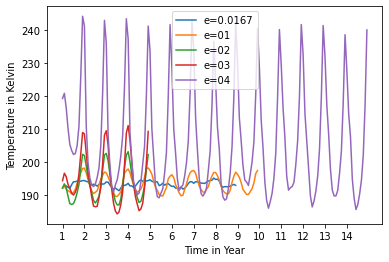

In [49]:

TTPT_e_default= LatWeightAnyVar_lat(T_obl0[0].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)
TTPT_e01= LatWeightAnyVar_lat(T_obl0[1].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)
TTPT_e02= LatWeightAnyVar_lat(T_obl0[2].T[:,-23,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)
TTPT_e03= LatWeightAnyVar_lat(T_obl0[3].T[:,-24,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)
TTPT_e04= LatWeightAnyVar_lat(T_obl0[4].T[:,-28,:,:],lat_low=-23.5,lat_high=23.5,timemean=False,withlev=False)

plt.plot(TTPT_e_default,label='e=0.0167')
plt.plot(TTPT_e01,label='e=01')
plt.plot(TTPT_e02,label='e=02')
plt.plot(TTPT_e03,label='e=03')
plt.plot(TTPT_e04,label='e=04')

plt.xticks(range(0,168,12),labels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14'])

plt.legend(loc='best')

plt.ylabel("Temperature in Kelvin")

plt.xlabel("Time in Year")
#plt.title('Monthly Mean Tropical Tropopause Temperature')

print('this is not correct because tropopause altitude increases with time')



As the tropopause altitude increases each year for e04 case, and tropical tropopause is different from the global,so I take the 14 years time average of vertical temperature and find the mean pressure level of tropopause


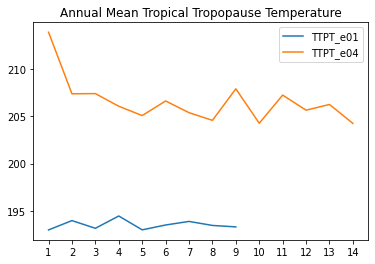

In [50]:
TTPT_e01_annual=[]

TTPT_e04_annual=[]

for i in range(9):
    TTPT_e01_annual.append(np.mean(TTPT_e01[i*12:(i+1)*12]))
    
for i in range(14):
    TTPT_e04_annual.append(np.mean(TTPT_e04[i*12:(i+1)*12]))


plt.plot(TTPT_e01_annual,label='TTPT_e01')

plt.plot(TTPT_e04_annual,label='TTPT_e04')

plt.xticks(range(0,14),labels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14'])

plt.legend()

plt.title('Annual Mean Tropical Tropopause Temperature')
print("As the tropopause altitude increases each year for e04 case, and tropical tropopause is different from the global," 
      +"so I take the 14 years time average"+
      " of vertical temperature and find the mean pressure level of tropopause")

<ipython-input-51-8775c16f2960>:41: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  axes[1].set_yticks([30, 10, 1], [30, 10, 1])
<ipython-input-51-8775c16f2960>:46: MatplotlibDeprecationWarning: Passing the minor parameter of set_ticks() positionally is deprecated since Matplotlib 3.2; the parameter will become keyword-only two minor releases later.
  axes[0].set_yticks([30, 10, 1], [30, 10, 1])


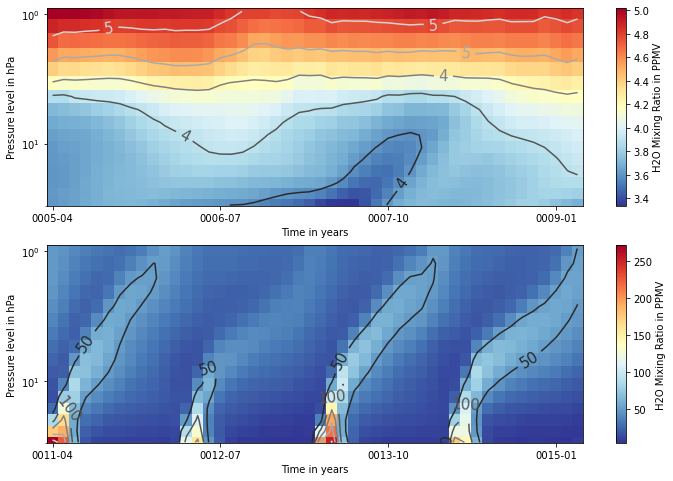

In [51]:
# for stratopause 



# lower limit is set [:,-44:-23,:,:] for e= 0.4 but to let them in the same scale, set both at z level [-28]
H2O_e_default_time_tr = LatWeightAnyVar_lat_test(H2O_obl0[0].H2O[:,-44:-28,:,:]*10**6,lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=slice(48, 96))

H2O_e04_time_tr = LatWeightAnyVar_lat_test(H2O_obl0[4].H2O[:,-44:-28,:,:]*10**6,lat_low=36,lat_high=-36,timemean=False,withlev=True).isel(time=slice(120, 168))
##########################################################################################################

fig, axes = plt.subplots(2,figsize=(12,8))

H2O_e_default_time_tr.plot(x='time',cmap='RdYlBu_r',ax=axes[0],yscale='log',yincrease=False,cbar_kwargs={"label": "H2O Mixing Ratio in PPMV"})   #,vmin=2, vmax=7)

H2O_e_default_time_tr_contour=H2O_e_default_time_tr.plot.contour(x='time',cmap='gray',ax=axes[0],yscale='log',yincrease=False)

axes[0].clabel(H2O_e_default_time_tr_contour, inline=True, fontsize=15,fmt='%1.f')

#plt.title('Tropical Mean of Water Vapor Mixing Ratio in PPMV for e=0.0167',fontsize=12)

# plt.xlabel('Time in years')

# plt.ylabel("Pressure level in hPa")

# plt.ylim([30,0.9])
# plt.yticks([30, 10, 1], [30, 10, 1])

# plt.show()
#########################################################################################################

H2O_e04_time_tr.plot(x='time',cmap='RdYlBu_r',ax=axes[1],yscale='log',yincrease=False,cbar_kwargs={"label": "H2O Mixing Ratio in PPMV"})#,vmin=10,vmax=100)

H2O_e04_time_tr_contour=H2O_e04_time_tr.plot.contour(x='time',cmap='gray',ax=axes[1],yscale='log',yincrease=False)

axes[1].clabel(H2O_e04_time_tr_contour, inline=True, fontsize=15,fmt='%1.f')

#plt.title('Tropical Mean of Water Vapor Mixing Ratio in PPMV for e=0.4',fontsize=15)
axes[1].set_xlabel('Time in years')
axes[1].set_ylabel("Pressure level in hPa")
axes[1].set_ylim([30,0.9])
axes[1].set_yticks([30, 10, 1], [30, 10, 1])

axes[0].set_xlabel('Time in years')
axes[0].set_ylabel("Pressure level in hPa")
axes[0].set_ylim([30,0.9])
axes[0].set_yticks([30, 10, 1], [30, 10, 1])

plt.show()
#########################################################################################################

Text(0, 0.5, 'Pressure in hPa')

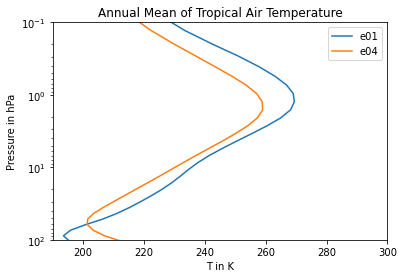

In [52]:
TTPT_e01_mean_v = LatWeightAnyVar_lat(T_obl0[1].T,lat_low=-23.5,lat_high=23.5,timemean=True,withlev=True)

TTPT_e04_mean_v = LatWeightAnyVar_lat(T_obl0[4].T,lat_low=-23.5,lat_high=23.5,timemean=True,withlev=True)



plt.plot(TTPT_e01_mean_v,T_obl0[1].T.lev,label='e01')

plt.plot(TTPT_e04_mean_v,T_obl0[1].T.lev,label='e04')

plt.gca().invert_yaxis()

plt.yscale('log')


plt.ylim([100,0.1])

plt.xlim([190,300])

plt.legend()

plt.title("Annual Mean of Tropical Air Temperature")

plt.xlabel('T in K')

plt.ylabel('Pressure in hPa')

In [53]:
# the tropical tropopause pressure level is:

print("the tropical tropopause pressure level for e01 is (hPa):",T_obl0[1].T.lev.values[-23])

print("the tropical tropopause pressure level for e04 is (hPa):",T_obl0[4].T.lev.values[-27])

the tropical tropopause pressure level for e01 is (hPa): 87.82123029232025
the tropical tropopause pressure level for e04 is (hPa): 43.1937500834465


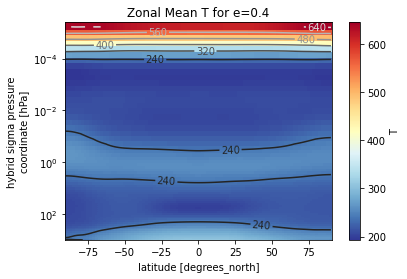

In [54]:
fig, axes = plt.subplots()

Zonal_T4 = T_obl0[4].T.mean(dim='lon').mean(dim='time').plot.contour(x='lat',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(Zonal_T4, inline=True, fontsize=10,fmt='%1.f')

T_obl0[4].T.mean(dim='lon').mean(dim='time').plot(x='lat',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)

axes.set_title('Zonal Mean T for e=0.4')

plt.show()

###########################


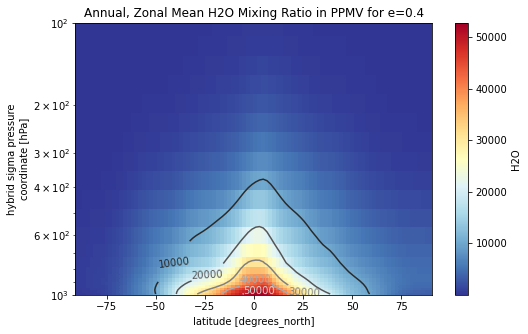

In [55]:
fig, axes = plt.subplots(figsize=(8,5))

Zonal_H2O4_pre = 10**6*H2O_obl0[4].H2O

Zonal_H2O4 =Zonal_H2O4_pre.mean(dim='lon').mean(dim='time').plot.contour(x='lat',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(Zonal_H2O4, inline=True, fontsize=10,fmt='%1.f')

Zonal_H2O4_pre.mean(dim='lon').mean(dim='time').plot(x='lat',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)

#axes.set_title('Zonal Mean H2O for e=0.4')

plt.ylim([1000,100])
plt.title('Annual, Zonal Mean H2O Mixing Ratio in PPMV for e=0.4')
plt.show()

###########################

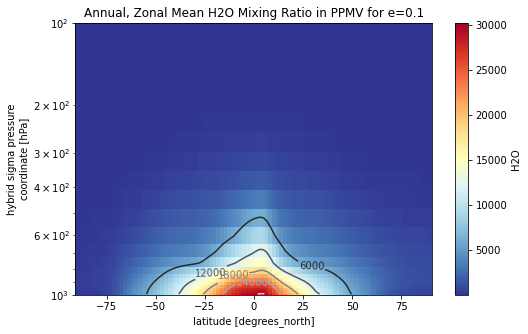

In [56]:
fig, axes = plt.subplots(figsize=(8,5))

Zonal_H2O1_pre = 10**6*H2O_obl0[1].H2O

Zonal_H2O1 =Zonal_H2O1_pre.mean(dim='lon').mean(dim='time').plot.contour(x='lat',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(Zonal_H2O1, inline=True, fontsize=10,fmt='%1.f')

Zonal_H2O1_pre.mean(dim='lon').mean(dim='time').plot(x='lat',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)

plt.title('Annual, Zonal Mean H2O Mixing Ratio in PPMV for e=0.1')

plt.ylim([1000,100])
plt.show()

###########################

/home/home02/pybl/.conda/envs/myenv/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/home02/pybl/.conda/envs/myenv/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


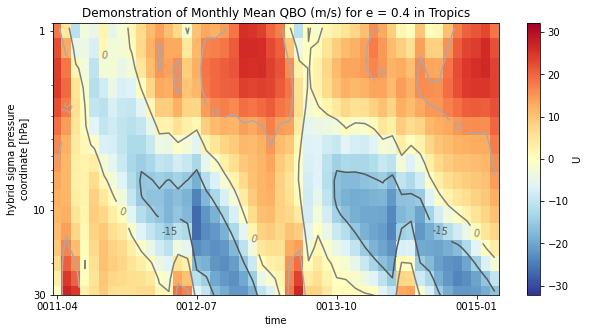

/home/home02/pybl/.conda/envs/myenv/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/home02/pybl/.conda/envs/myenv/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


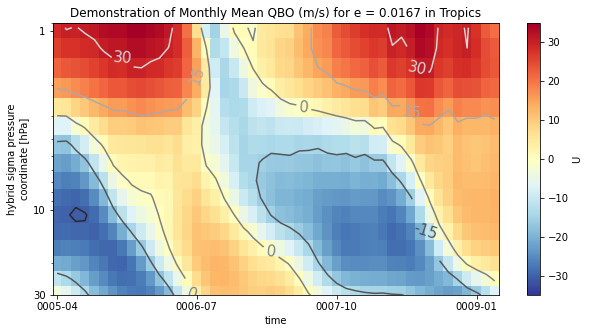

/home/home02/pybl/.conda/envs/myenv/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)
/home/home02/pybl/.conda/envs/myenv/lib/python3.9/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


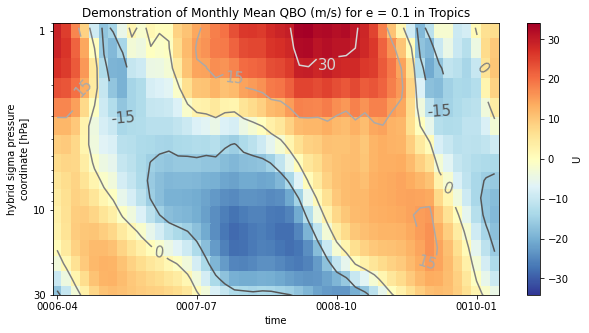

In [57]:
fig, axes = plt.subplots(figsize=(10,5))

QBO_e04 = U_obl0[4].U.where((U_obl0[4].lat > -23.5 ) & (U_obl0[4].lat < 23.5) & (U_obl0[4].lev < 100)& (U_obl0[4].lev > 0.9)).isel(time=slice(120, 168)).mean(['lon','lat']).plot.contour(x='time',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(QBO_e04, inline=True, fontsize=10,fmt='%1.f')

U_obl0[4].U.where((U_obl0[4].lat > -23.5 ) & (U_obl0[4].lat < 23.5) & (U_obl0[4].lev < 100)& (U_obl0[4].lev > 0.9)).isel(time=slice(120, 168)).mean(['lon','lat']).plot(x='time',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)

plt.ylim([30,0.9])
plt.yticks([30, 10, 1], [30, 10, 1])
plt.title('Demonstration of Monthly Mean QBO (m/s) for e = 0.4 in Tropics')
plt.show()
#########################################################################################################

fig, axes = plt.subplots(figsize=(10,5))

QBO_e_default = U_obl0[0].U.where((U_obl0[0].lat > -23.5 ) & (U_obl0[0].lat < 23.5) & (U_obl0[0].lev < 100)& (U_obl0[0].lev > 0.9)).isel(time=slice(48, 96)).mean(['lon','lat']).plot.contour(x='time',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(QBO_e_default, inline=True, fontsize=15,fmt='%1.f')

U_obl0[0].U.where((U_obl0[0].lat > -23.5 ) & (U_obl0[0].lat < 23.5) & (U_obl0[0].lev < 100)& (U_obl0[0].lev > 0.9)).isel(time=slice(48, 96)).mean(['lon','lat']).plot(x='time',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)
plt.ylim([30,0.9])
plt.yticks([30, 10, 1], [30, 10, 1])
plt.title('Demonstration of Monthly Mean QBO (m/s) for e = 0.0167 in Tropics')
plt.show()

#########################################################################################################

fig, axes = plt.subplots(figsize=(10,5))

QBO_e01 = U_obl0[1].U.where((U_obl0[1].lat > -23.5 ) & (U_obl0[1].lat < 23.5) & (U_obl0[1].lev < 100)& (U_obl0[1].lev > 0.9)).isel(time=slice(60, 108)).mean(['lon','lat']).plot.contour(x='time',cmap='gray',ax=axes,yscale='log',yincrease=False)

axes.clabel(QBO_e01, inline=True, fontsize=15,fmt='%1.f')

U_obl0[1].U.where((U_obl0[1].lat > -23.5 ) & (U_obl0[1].lat < 23.5) & (U_obl0[1].lev < 100)& (U_obl0[1].lev > 0.9)).isel(time=slice(60, 108)).mean(['lon','lat']).plot(x='time',cmap='RdYlBu_r',ax=axes,yscale='log',yincrease=False)
plt.ylim([30,0.9])
plt.yticks([30, 10, 1], [30, 10, 1])
plt.title('Demonstration of Monthly Mean QBO (m/s) for e = 0.1 in Tropics')
plt.show()

how should I quantify the effect of QBO on stratospheric water?

In [58]:
U_obl0[0].U.where((U_obl0[0].lat > -23.5 ) & (U_obl0[0].lat < 23.5) & (U_obl0[0].lev < 100)& (U_obl0[0].lev > 1)).isel(time=slice(30, 96)).mean(['lon','lat'])

<xarray.DataArray 'U' (time: 66, lev: 70)>
dask.array<mean_agg-aggregate, shape=(66, 70), dtype=float32, chunksize=(66, 70), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 0003-10-01 00:00:00 ... 0009-03-01 00:00:00
  * lev      (lev) float64 5.96e-06 9.827e-06 1.62e-05 ... 957.5 976.3 992.6